In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

In [5]:
from sklearn.mixture import GaussianMixture

In [6]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

clusters = gmm.fit_predict(X)

In [7]:
df["Cluster"] = clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


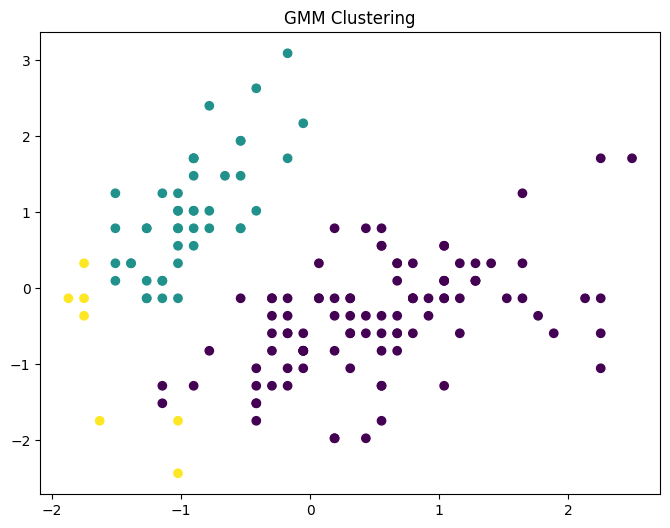

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("GMM Clustering")

plt.show()

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.4751434694267145


In [10]:
probabilities = gmm.predict_proba(X)

probabilities[:5]

array([[2.74503381e-011, 1.00000000e+000, 0.00000000e+000],
       [1.16033052e-007, 9.99999884e-001, 0.00000000e+000],
       [9.72921434e-009, 9.99999990e-001, 5.88168010e-278],
       [2.02193473e-007, 9.99999798e-001, 3.33173699e-141],
       [9.67775891e-012, 1.00000000e+000, 0.00000000e+000]])

In [11]:
gmm.means_

array([[ 0.53745909, -0.39369142,  0.6693573 ,  0.64500292],
       [-0.93852253,  0.98617415, -1.29410958, -1.24871335],
       [-1.53616188, -0.9148767 , -1.05760659, -1.00758605]])